Imports And Configurations

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#Install dependencies

import os
import numpy as np
import pandas as pd

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

import torchvision.transforms as transforms
import torchvision.models as models

from collections import Counter
from sklearn.model_selection import train_test_split

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [3]:
captions = pd.read_csv("/content/drive/MyDrive/MMRetrieval/flickr30k/captions.txt")
unique_images = captions["image"].unique()

train_imgs, temp_imgs = train_test_split(
    unique_images,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

val_imgs, test_imgs = train_test_split(
    temp_imgs,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

In [5]:
for file in os.listdir("/content/drive/MyDrive/MMRetrieval/flickr30k"):
    print(file)

captions.txt


In [6]:
#Create tranin test data

captions = pd.read_csv(
    "/content/drive/MyDrive/MMRetrieval/flickr30k/captions.txt"
)

full_df = captions.copy()

unique_images = full_df["image"].unique()

train_imgs, temp_imgs = train_test_split(
    unique_images,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

val_imgs, test_imgs = train_test_split(
    temp_imgs,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

In [8]:
print(full_df.columns)

Index(['image', 'caption'], dtype='object')


In [9]:
# =====================================
# Create Train/Validation/Test DataFrames
# =====================================

train_df = full_df[
    full_df["image"].isin(train_imgs)
].reset_index(drop=True)

val_df = full_df[
    full_df["image"].isin(val_imgs)
].reset_index(drop=True)

test_df = full_df[
    full_df["image"].isin(test_imgs)
].reset_index(drop=True)

In [10]:
print("========== VERIFY ==========")

print(
    "Train Images :",
    train_df["image"].nunique()
)

print(
    "Train Rows   :",
    len(train_df)
)

print()

print(
    "Val Images :",
    val_df["image"].nunique()
)

print(
    "Val Rows   :",
    len(val_df)
)

print()

print(
    "Test Images :",
    test_df["image"].nunique()
)

print(
    "Test Rows   :",
    len(test_df)
)

========== VERIFY ==========
Train Images : 25426
Train Rows   : 127130

Val Images : 3178
Val Rows   : 15890

Test Images : 3179
Test Rows   : 15895


In [11]:
print(
    "Average captions per image"
)

print(
    len(train_df) /
    train_df["image"].nunique()
)

print(
    len(val_df) /
    val_df["image"].nunique()
)

print(
    len(test_df) /
    test_df["image"].nunique()
)

Average captions per image
5.0
5.0
5.0


In [12]:
train_df.to_csv(
    "/content/drive/MyDrive/MMRetrieval/splits_new/train_full.csv",
    index=False
)

val_df.to_csv(
    "/content/drive/MyDrive/MMRetrieval/splits_new/val_full.csv",
    index=False
)

test_df.to_csv(
    "/content/drive/MyDrive/MMRetrieval/splits_new/test_full.csv",
    index=False
)

In [13]:
#Verify No Leakage
print(
    len(
        set(train_imgs) & set(val_imgs)
    )
)

print(
    len(
        set(train_imgs) & set(test_imgs)
    )
)

print(
    len(
        set(val_imgs)  & set(test_imgs)
    )
)

0
0
0


In [14]:
#Check Split Statistics
print(
    "Train Images:",
    len(train_imgs)
)

print(
    "Validation Images:",
    len(val_imgs)
)

print(
    "Test Images:",
    len(test_imgs)
)

print()

print(
    "Train Rows:",
    len(train_df)
)

print(
    "Validation Rows:",
    len(val_df)
)

print(
    "Test Rows:",
    len(test_df)
)

Train Images: 25426
Validation Images: 3178
Test Images: 3179

Train Rows: 127130
Validation Rows: 15890
Test Rows: 15895


In [15]:
#saving train , val, test data

train_df.to_csv(
    "/content/drive/MyDrive/MMRetrieval/splits_new/train_full.csv",
    index=False
)

val_df.to_csv(
    "/content/drive/MyDrive/MMRetrieval/splits_new/val_full.csv",
    index=False
)

test_df.to_csv(
    "/content/drive/MyDrive/MMRetrieval/splits_new/test_fullcsv",
    index=False
)

Build Vocabulary.

In [17]:
print(train_df["caption"].isna().sum())

1


In [18]:
train_df[train_df["caption"].isna()].head()

,image,caption
16074,2199200615.jpg,NaN


In [19]:
train_df = train_df.dropna(subset=["caption"]).reset_index(drop=True)
val_df   = val_df.dropna(subset=["caption"]).reset_index(drop=True)
test_df  = test_df.dropna(subset=["caption"]).reset_index(drop=True)

In [20]:
# LSTM cannot read text. It needs integers

#count words

counter = Counter()

for caption in train_df["caption"]:
    counter.update(
        caption.lower().split()
    )
# Create vocabulary

vocab = {
    "<pad>":0,
    "<sos>":1,
    "<eos>":2,
    "<unk>":3
}



In [21]:
#Add words
for word,count in counter.items():

    if count >= 2:

        vocab[word] = len(vocab)
        print("Vocabulary Size:", len(vocab))

# Reverse Vocabulary
idx2word = {
    v:k
    for k,v in vocab.items()
}


# vocabulary size
print(
    "Vocabulary Size:",
    len(vocab)
)

Vocabulary Size: 5
Vocabulary Size: 6
Vocabulary Size: 7
Vocabulary Size: 8
Vocabulary Size: 9
Vocabulary Size: 10
Vocabulary Size: 11
Vocabulary Size: 12
Vocabulary Size: 13
Vocabulary Size: 14
Vocabulary Size: 15
Vocabulary Size: 16
Vocabulary Size: 17
Vocabulary Size: 18
Vocabulary Size: 19
Vocabulary Size: 20
Vocabulary Size: 21
Vocabulary Size: 22
Vocabulary Size: 23
Vocabulary Size: 24
Vocabulary Size: 25
Vocabulary Size: 26
Vocabulary Size: 27
Vocabulary Size: 28
Vocabulary Size: 29
Vocabulary Size: 30
Vocabulary Size: 31
Vocabulary Size: 32
Vocabulary Size: 33
Vocabulary Size: 34
Vocabulary Size: 35
Vocabulary Size: 36
Vocabulary Size: 37
Vocabulary Size: 38
Vocabulary Size: 39
Vocabulary Size: 40
Vocabulary Size: 41
Vocabulary Size: 42
Vocabulary Size: 43
Vocabulary Size: 44
Vocabulary Size: 45
Vocabulary Size: 46
Vocabulary Size: 47
Vocabulary Size: 48
Vocabulary Size: 49
Vocabulary Size: 50
Vocabulary Size: 51
Vocabulary Size: 52
Vocabulary Size: 53
Vocabulary Size: 54
Vocab

Caption Encoding

In [22]:
def encode_caption(
    caption,
    vocab,
    max_len=30
):

    tokens = [vocab["<sos>"]]

    for word in caption.lower().split():

        tokens.append(
            vocab.get(
                word,
                vocab["<unk>"]
            )
        )

    tokens.append(
        vocab["<eos>"]
    )

    if len(tokens) < max_len:

        tokens += [vocab["<pad>"]] * (
            max_len - len(tokens)
        )

    else:

        tokens = tokens[:max_len]

    return torch.tensor(tokens)

Dataset Class

In [28]:
if not os.path.exists("/content/flickr30k.zip"):
    !cp "/content/drive/MyDrive/MMRetrieval/flickr30k.zip" /content/


y


In [29]:
if not os.path.exists("/content/flickr30k"):
    !unzip -q "/content/flickr30k.zip" -d "/content/flickr30k"

y


In [30]:
print("Images:", len(os.listdir("/content/flickr30k/Images")))

Images: 31811


In [34]:
class FlickrDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_dir,
        vocab
    ):

        self.df = dataframe

        self.image_dir = image_dir

        self.vocab = vocab

        self.transform = transforms.Compose([

            transforms.Resize(
                (224,224)
            ),

            transforms.ToTensor(),

            transforms.Normalize(
                mean=[0.485,0.456,0.406],
                std=[0.229,0.224,0.225]
            )
        ])

    #length
    def __len__(self):
        return len(self.df)

    #Get Item
    def __getitem__(self,idx):

        row = self.df.iloc[idx]

        image_name = row["image"]

        caption = row["caption"]

        path = os.path.join(
            self.image_dir,
            image_name
        )

        image = Image.open(
            path
        ).convert("RGB")

        image = self.transform(image)

        caption = encode_caption(
            caption,
            self.vocab
        )

        return image,caption

In [35]:
#Create Dataset and Data Loader

image_dir = "/content/flickr30k/Images"
captions = pd.read_csv("/content/flickr30k/captions.txt")

train_dataset = FlickrDataset(
    train_df,
    image_dir,
    vocab
)

val_dataset = FlickrDataset(
    val_df,
    image_dir,
    vocab
)

test_dataset = FlickrDataset(
    test_df,
    image_dir,
    vocab
)

In [36]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2
)
val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

In [37]:
print(image_dir)

/content/flickr30k/Images


In [38]:
images, captions = next(iter(train_loader))

print(images.shape)
print(type(captions))

torch.Size([64, 3, 224, 224])
<class 'torch.Tensor'>


In [39]:
class ImageEncoder(nn.Module):

    def __init__(self):

        super().__init__()

        backbone = models.resnet50(
            weights=models.ResNet50_Weights.DEFAULT
        )

        backbone.fc = nn.Identity()

        self.backbone = backbone

        # Freeze all ResNet layers
        for param in self.backbone.parameters():
            param.requires_grad = False

        self.projection = nn.Linear(
         2048,
         256
        )

        #Unfreeze layer 3
        for param in self.backbone.layer3.parameters():
            param.requires_grad = True

        # Unfreeze Layer 4
        for param in self.backbone.layer4.parameters():
            param.requires_grad = True

        # Optional but doing for projection layer too explicityly

        for param in self.projection.parameters():
            param.requires_grad = True

    #Forward
    def forward(self,x):

        x = self.backbone(x)

        x = self.projection(x)

        x = F.normalize(
            x,
            dim=1
        )

        return x

In [40]:
import torch.nn as nn
import torch.nn.functional as F

#LSTM TEXT Encoder
class TextEncoder(nn.Module):

    def __init__(
        self,
        vocab_size
    ):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            300,
            padding_idx=0
        )
#LSTM
        self.lstm = nn.LSTM(
            300,
            512,
            num_layers=2,
            dropout=0.3,
            batch_first=True
        )


        # --------------------------
        # NEW: Attention Layer
        # --------------------------
        self.attention = nn.Linear(
            512,
            1
        )

        # Projection
        self.projection = nn.Linear(
            512,
            256
        )

    def forward(self, x):

        # Word Embeddings
        x = self.embedding(x)

        # LSTM Outputs
        output, (hidden, _) = self.lstm(x)

        # --------------------------------
        # Attention Scores
        # output shape:
        # (batch_size, sequence_length, 512)
        # --------------------------------

        attention_scores = self.attention(output)

        # --------------------------------
        # Convert scores to probabilities
        # --------------------------------

        attention_weights = torch.softmax(
            attention_scores,
            dim=1
        )

        # --------------------------------
        # Weighted Sum of all LSTM outputs
        # --------------------------------

        context = torch.sum(
            attention_weights * output,
            dim=1
        )

        # Projection Layer
        x = self.projection(context)

        # Normalize
        x = F.normalize(
            x,
            dim=1
        )

        return x

In [41]:
#Clip Style Loss
class CLIPLoss(nn.Module):

    def __init__(
        self,
        temperature=0.07
    ):

        super().__init__()

        self.ce = nn.CrossEntropyLoss()

        self.temperature = temperature
 #Forward
    def forward(
        self,
        image_emb,
        text_emb
    ):

        logits = (
    image_emb @ text_emb.T
) / self.temperature

        targets = torch.arange(
            logits.size(0)
        ).to(device)

        image_loss = self.ce(
            logits,
            targets
        )

        text_loss = self.ce(
            logits.T,
            targets
        )

        loss = (
            image_loss +
            text_loss
        ) / 2

        return loss

In [45]:
# ==================================
# Create Models
# ==================================

image_encoder = ImageEncoder().to(device)

text_encoder = TextEncoder(
    len(vocab)
).to(device)


# ==================================
# Verify Frozen Layers (Run Once)
# ==================================

print("===== Trainable Parameters =====")

for name, param in image_encoder.named_parameters():

    if param.requires_grad:

        print("Trainable :", name)

    else:

        print("Frozen    :", name)


# ==================================
# Loss Function
# ==================================

criterion = CLIPLoss()


# ==================================
# Optimizer
# ==================================

optimizer = torch.optim.Adam(

    filter(
        lambda p: p.requires_grad,

        list(image_encoder.parameters()) +
        list(text_encoder.parameters())
    ),

    lr=1e-4
)


# ==================================
# Training Configurations
# ==================================

# epochs = 10

# best_val_loss = float("inf")

epochs = 50

best_val_loss = float("inf")

patience = 5

counter = 0

train_losses = []

val_losses = []

===== Trainable Parameters =====
Frozen    : backbone.conv1.weight
Frozen    : backbone.bn1.weight
Frozen    : backbone.bn1.bias
Frozen    : backbone.layer1.0.conv1.weight
Frozen    : backbone.layer1.0.bn1.weight
Frozen    : backbone.layer1.0.bn1.bias
Frozen    : backbone.layer1.0.conv2.weight
Frozen    : backbone.layer1.0.bn2.weight
Frozen    : backbone.layer1.0.bn2.bias
Frozen    : backbone.layer1.0.conv3.weight
Frozen    : backbone.layer1.0.bn3.weight
Frozen    : backbone.layer1.0.bn3.bias
Frozen    : backbone.layer1.0.downsample.0.weight
Frozen    : backbone.layer1.0.downsample.1.weight
Frozen    : backbone.layer1.0.downsample.1.bias
Frozen    : backbone.layer1.1.conv1.weight
Frozen    : backbone.layer1.1.bn1.weight
Frozen    : backbone.layer1.1.bn1.bias
Frozen    : backbone.layer1.1.conv2.weight
Frozen    : backbone.layer1.1.bn2.weight
Frozen    : backbone.layer1.1.bn2.bias
Frozen    : backbone.layer1.1.conv3.weight
Frozen    : backbone.layer1.1.bn3.weight
Frozen    : backbone.lay

In [43]:
print(
    full_df["image"].nunique()
)

31783


In [44]:
print(len(train_df))
print(len(val_df))
print(len(test_df))

127129
15890
15895


In [47]:
for epoch in range(epochs):

    image_encoder.train()
    text_encoder.train()

    running_loss = 0

    # ------------------
    # TRAINING
    # ------------------

    for images, captions in train_loader:

        images = images.to(device)
        captions = captions.to(device)

        img_emb = image_encoder(images)
        txt_emb = text_encoder(captions)

        loss = criterion(
            img_emb,
            txt_emb
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    train_losses.append(train_loss)

    # ------------------
    # VALIDATION
    # ------------------

    image_encoder.eval()
    text_encoder.eval()

    val_loss = 0

    with torch.no_grad():

        for images, captions in val_loader:

            images = images.to(device)
            captions = captions.to(device)

            img_emb = image_encoder(images)
            txt_emb = text_encoder(captions)

            loss = criterion(
                img_emb,
                txt_emb
            )

            val_loss += loss.item()

    val_loss = val_loss / len(val_loader)

    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")

    # ==================================
    # SAVE BEST MODEL
    # ==================================

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        counter = 0

        torch.save(
            image_encoder.state_dict(),
            "/content/drive/MyDrive/MMRetrieval/models/best_image_encoder_new.pth"
        )

        torch.save(
            text_encoder.state_dict(),
            "/content/drive/MyDrive/MMRetrieval/models/best_text_encoder_new.pth"
        )

        print("✅ Best model saved.")

    else:

        counter += 1

        print(f"No improvement for {counter} epoch(s).")

    # ==================================
    # EARLY STOPPING
    # ==================================

    if counter >= patience:

        print("\nEarly stopping triggered.")

        break

Epoch 1
Train Loss: 1.7455
Val Loss: 2.4915
✅ Best model saved.
Epoch 2
Train Loss: 0.7691
Val Loss: 2.4141
✅ Best model saved.
Epoch 3
Train Loss: 0.4917
Val Loss: 2.3906
✅ Best model saved.
Epoch 4
Train Loss: 0.3624
Val Loss: 2.3935
No improvement for 1 epoch(s).
Epoch 5
Train Loss: 0.2828
Val Loss: 2.3760
✅ Best model saved.
Epoch 6
Train Loss: 0.2338
Val Loss: 2.3736
✅ Best model saved.
Epoch 7
Train Loss: 0.1979
Val Loss: 2.3478
✅ Best model saved.
Epoch 8
Train Loss: 0.1700
Val Loss: 2.3582
No improvement for 1 epoch(s).
Epoch 9
Train Loss: 0.1528
Val Loss: 2.3295
✅ Best model saved.
Epoch 10
Train Loss: 0.1353
Val Loss: 2.3456
No improvement for 1 epoch(s).
Epoch 11
Train Loss: 0.1230
Val Loss: 2.3439
No improvement for 2 epoch(s).
Epoch 12
Train Loss: 0.1136
Val Loss: 2.3349
No improvement for 3 epoch(s).
Epoch 13
Train Loss: 0.1032
Val Loss: 2.3282
✅ Best model saved.


KeyboardInterrupt: 

In [ ]:
image_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [48]:
import os

print(
    os.path.exists(
        "/content/drive/MyDrive/MMRetrieval/models-fulldata"
    )
)

True


In [50]:
from torchvision import transforms

image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [51]:
#After Training


image_encoder.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/MMRetrieval/models/best_image_encoder_new.pth"
    )
)

text_encoder.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/MMRetrieval/models/best_text_encoder_new.pth"
    )
)

image_encoder.eval()
text_encoder.eval()

# =====================================
# Generate UNIQUE Image Embeddings
# =====================================

test_unique_images = (
    test_df["image"]
    .drop_duplicates()
    .reset_index(drop=True)
)

print(
    "Unique Test Images:",
    len(test_unique_images)
)

image_embeddings = []
image_ids = []

with torch.no_grad():

    for image_name in test_unique_images:

        image_path = os.path.join(
            image_dir,
            image_name
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        image = image_transform(
            image
        ).unsqueeze(0)

        image = image.to(device)

        emb = image_encoder(image)

        image_embeddings.append(
            emb.cpu().numpy()[0]
        )

        image_ids.append(
            image_name
        )
        print(image_ids[:5])

        print(test_unique_images.head())

image_embeddings = np.array(
    image_embeddings
)

image_embeddings = image_embeddings / np.linalg.norm(
    image_embeddings,
    axis=1,
    keepdims=True
)

print(
    "Image Embeddings Shape:",
    image_embeddings.shape
)


Streaming output truncated to the last 5000 lines.
Name: image, dtype: object
['1003163366.jpg', '101093029.jpg', '101362650.jpg', '1021293940.jpg', '102860573.jpg']
0    1003163366.jpg
1     101093029.jpg
2     101362650.jpg
3    1021293940.jpg
4     102860573.jpg
Name: image, dtype: object
['1003163366.jpg', '101093029.jpg', '101362650.jpg', '1021293940.jpg', '102860573.jpg']
0    1003163366.jpg
1     101093029.jpg
2     101362650.jpg
3    1021293940.jpg
4     102860573.jpg
Name: image, dtype: object
['1003163366.jpg', '101093029.jpg', '101362650.jpg', '1021293940.jpg', '102860573.jpg']
0    1003163366.jpg
1     101093029.jpg
2     101362650.jpg
3    1021293940.jpg
4     102860573.jpg
Name: image, dtype: object
['1003163366.jpg', '101093029.jpg', '101362650.jpg', '1021293940.jpg', '102860573.jpg']
0    1003163366.jpg
1     101093029.jpg
2     101362650.jpg
3    1021293940.jpg
4     102860573.jpg
Name: image, dtype: object
['1003163366.jpg', '101093029.jpg', '101362650.jpg', '10212939

In [52]:
# =====================================
# Generate Caption Embeddings
# =====================================

caption_embeddings = []

captions_list = []

with torch.no_grad():

    for _, row in test_df.iterrows():

        caption = row["caption"]

        encoded = encode_caption(
            caption,
            vocab
        )

        encoded = (
            encoded
            .unsqueeze(0)
            .to(device)
        )

        emb = text_encoder(
            encoded
        )

        caption_embeddings.append(
            emb.cpu().numpy()[0]
        )

        captions_list.append(
            caption
        )

caption_embeddings = np.array(
    caption_embeddings
)

caption_embeddings = caption_embeddings / np.linalg.norm(
    caption_embeddings,
    axis=1,
    keepdims=True
)

print(
    "Caption Embeddings Shape:",
    caption_embeddings.shape
)

Caption Embeddings Shape: (15895, 256)


In [53]:
#Save to Drive
np.save(
    "/content/drive/MyDrive/MMRetrieval/custom_image_embeddings_subset4_new.npy",
    image_embeddings
)

np.save(
    "/content/drive/MyDrive/MMRetrieval/custom_text_embeddings_subset4_new.npy",
    caption_embeddings
)

In [54]:
#Save Metadata

import pickle

with open(
    "/content/drive/MyDrive/MMRetrieval/custom_image_ids_subset4_new.pkl",
    "wb"
) as f:

    pickle.dump(
        image_ids,
        f
    )
# captions metadata

with open(
    "/content/drive/MyDrive/MMRetrieval/custom_captions_subset4_new.pkl",
    "wb"
) as f:

    pickle.dump(
        captions_list,
        f
    )

In [55]:
#save to CSV

caption_metadata = test_df[
    ["image", "caption"]
].reset_index(drop=True)

caption_metadata.to_csv(
    "/content/drive/MyDrive/MMRetrieval/custom_caption_metadata_subset4_new.csv",
    index=False
)

Image → Text Retrieval
Retrieve Top-5 Captions for an Image

Query Image:
1078621572.jpg


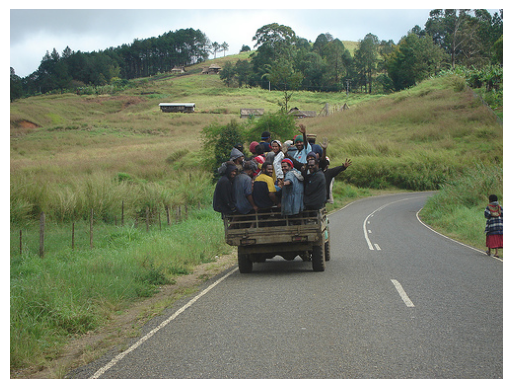


Top 5 Retrieved Captions:

Top-1 | Score=0.7307
 A group of tourists are riding a caravan of camels on a dirt road .
--------------------------------------------------------------------------------
Top-2 | Score=0.7216
 Woman and boy in on the road with 2 bulls pulling a wagon .
--------------------------------------------------------------------------------
Top-3 | Score=0.7038
 A group of tourists riding camels on a dirt path accompanied by pedestrians .
--------------------------------------------------------------------------------
Top-4 | Score=0.6920
 A group of people riding in the back of a truck , down the road , in a country area .
--------------------------------------------------------------------------------
Top-5 | Score=0.6916
 People walk along a path in a village in India .
--------------------------------------------------------------------------------


In [56]:
#Image → Text Retrieval
# Retrieve Top-5 Captions for an Image

# =====================================
# Image -> Text Retrieval
# =====================================

from PIL import Image
import matplotlib.pyplot as plt

query_img_idx = 13

query_image_name = image_ids[query_img_idx]

query_embedding = image_embeddings[query_img_idx]

scores = query_embedding @ caption_embeddings.T

top5 = scores.argsort()[-5:][::-1]

print("Query Image:")
print(query_image_name)

img_path = os.path.join(
    image_dir,
    query_image_name
)

img = Image.open(img_path)

plt.imshow(img)
plt.axis("off")
plt.show()

print("\nTop 5 Retrieved Captions:\n")

for rank, caption_idx in enumerate(top5):

    print(
        f"Top-{rank+1} | Score={scores[caption_idx]:.4f}"
    )

    print(
        captions_list[caption_idx]
    )

    print("-"*80)

In [57]:
#Text → Image Retrieval
#Retrieve Top-5 Images for a Caption

# =====================================
# Text -> Image Retrieval
# =====================================

query_text_idx = 20

query_caption = captions_list[query_text_idx]

query_embedding = caption_embeddings[query_text_idx]

scores = query_embedding @ image_embeddings.T

top5 = scores.argsort()[-5:][::-1]

print("Query Caption:\n")
print(query_caption)

print("\nTop 5 Retrieved Images:\n")

for rank, img_idx in enumerate(top5):

    print(
        f"Top-{rank+1} | Score={scores[img_idx]:.4f}"
    )

    print(
        image_ids[img_idx]
    )

    print("-"*60)

Query Caption:

 A construction site on a street with three men working .

Top 5 Retrieved Images:

Top-1 | Score=0.7106
7333560206.jpg
------------------------------------------------------------
Top-2 | Score=0.6549
102860573.jpg
------------------------------------------------------------
Top-3 | Score=0.6344
515797344.jpg
------------------------------------------------------------
Top-4 | Score=0.6002
3711340791.jpg
------------------------------------------------------------
Top-5 | Score=0.5842
4561852553.jpg
------------------------------------------------------------


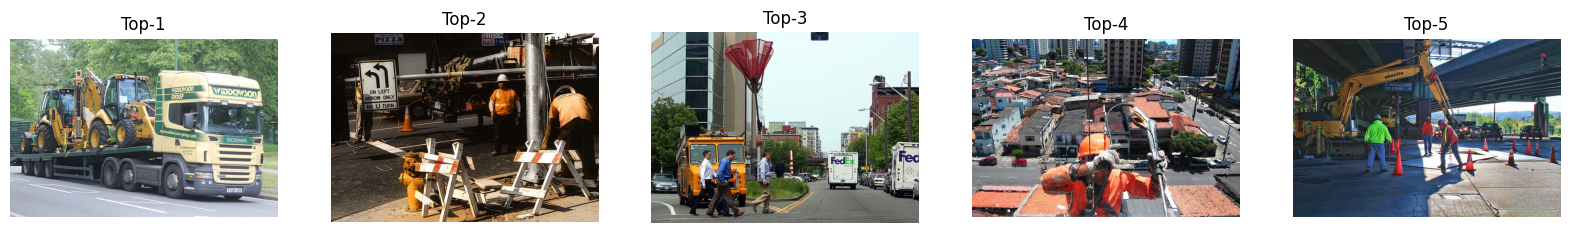

In [58]:
#Optional: Show Retrieved Images .. chk

fig, axes = plt.subplots(
    1,
    5,
    figsize=(20,4)
)

for i, img_idx in enumerate(top5):

    img_path = os.path.join(
        image_dir,
        image_ids[img_idx]
    )

    img = Image.open(img_path)

    axes[i].imshow(img)
    axes[i].axis("off")

    axes[i].set_title(
        f"Top-{i+1}"
    )

plt.show()

In [59]:

# =====================================
# Text -> Text Retrieval
# =====================================

query_text_idx = 0

query_caption = captions_list[query_text_idx]

query_embedding = caption_embeddings[query_text_idx]

scores = query_embedding @ caption_embeddings.T

# Remove self match
scores[query_text_idx] = -1

top5 = scores.argsort()[-5:][::-1]

print("Query Caption:\n")
print(query_caption)

print("\nTop 5 Similar Captions:\n")

for rank, idx in enumerate(top5):

    print(
        f"Top-{rank+1} | Score={scores[idx]:.4f}"
    )

    print(
        captions_list[idx]
    )

    print("-"*80)

Query Caption:

 a man sleeping on a bench outside with a white and black dog sitting next to him .

Top 5 Similar Captions:

Top-1 | Score=0.8210
 A man lays on a bench while his dog sits by him .
--------------------------------------------------------------------------------
Top-2 | Score=0.7799
 A black-haired man is sleeping on a bench in a city street .
--------------------------------------------------------------------------------
Top-3 | Score=0.7487
 A man is sitting on a gray bench .
--------------------------------------------------------------------------------
Top-4 | Score=0.7339
 A man is sleeping inside on a bench with his hat over his eyes .
--------------------------------------------------------------------------------
Top-5 | Score=0.7164
 Two men are sitting on a wooden bench sleeping on each other .
--------------------------------------------------------------------------------


Quantitative Evaluation

In [60]:
# Creating mappings
from collections import defaultdict

# image -> list of captions

image_to_captions = defaultdict(list)

for _, row in test_df.iterrows():

    image_to_captions[row["image"]].append(
        row["caption"]
    )

In [61]:
#Image to Text Evaluation

correct_top1 = 0
correct_top5 = 0

total = len(image_ids)

for img_idx, image_name in enumerate(image_ids):

    query_embedding = image_embeddings[img_idx]

    scores = query_embedding @ caption_embeddings.T

    top5 = scores.argsort()[-5:][::-1]

    retrieved_captions = [
        captions_list[idx]
        for idx in top5
    ]

    ground_truth = image_to_captions[
        image_name
    ]

    # Top-1

    if retrieved_captions[0] in ground_truth:

        correct_top1 += 1

    # Top-5

    if any(
        cap in ground_truth
        for cap in retrieved_captions
    ):

        correct_top5 += 1

image_text_top1 = (
    correct_top1 / total
) * 100

image_text_top5 = (
    correct_top5 / total
) * 100

print(
    f"Image→Text Top1 : {image_text_top1:.2f}%"
)

print(
    f"Image→Text Top5 : {image_text_top5:.2f}%"
)

Image→Text Top1 : 25.51%
Image→Text Top5 : 49.86%


In [62]:
# Build Caption → Image Ground Truth

caption_to_image = {}

for _, row in test_df.iterrows():

    caption_to_image[
        row["caption"]
    ] = row["image"]

In [63]:
#Text to Image Evaluation

correct_top1 = 0
correct_top5 = 0

total = len(captions_list)

for txt_idx, caption in enumerate(
    captions_list
):

    query_embedding = caption_embeddings[
        txt_idx
    ]

    scores = (
        query_embedding
        @ image_embeddings.T
    )

    top5 = scores.argsort()[-5:][::-1]

    retrieved_images = [
        image_ids[idx]
        for idx in top5
    ]

    gt_image = caption_to_image[
        caption
    ]

    # Top-1

    if retrieved_images[0] == gt_image:

        correct_top1 += 1

    # Top-5

    if gt_image in retrieved_images:

        correct_top5 += 1

text_image_top1 = (
    correct_top1 / total
) * 100

text_image_top5 = (
    correct_top5 / total
) * 100

print(
    f"Text→Image Top1 : {text_image_top1:.2f}%"
)

print(
    f"Text→Image Top5 : {text_image_top5:.2f}%"
)

Text→Image Top1 : 18.29%
Text→Image Top5 : 41.41%


In [64]:
#Text to Text Evaluation

correct_top1 = 0
correct_top5 = 0

total = len(captions_list)

for txt_idx, caption in enumerate(
    captions_list
):

    query_embedding = caption_embeddings[
        txt_idx
    ]

    scores = (
        query_embedding
        @ caption_embeddings.T
    )

    scores[txt_idx] = -1

    top5 = scores.argsort()[-5:][::-1]

    query_image = caption_to_image[
        caption
    ]

    retrieved_images = []

    for idx in top5:

        retrieved_images.append(

            caption_to_image[
                captions_list[idx]
            ]
        )

    # Top1

    if retrieved_images[0] == query_image:

        correct_top1 += 1

    # Top5

    if query_image in retrieved_images:

        correct_top5 += 1

text_text_top1 = (
    correct_top1 / total
) * 100

text_text_top5 = (
    correct_top5 / total
) * 100

print(
    f"Text→Text Top1 : {text_text_top1:.2f}%"
)

print(
    f"Text→Text Top5 : {text_text_top5:.2f}%"
)

Text→Text Top1 : 41.77%
Text→Text Top5 : 64.71%


Qualitative Evaluation

In [65]:
# Image to Text

query_idx = 10

query_image = image_ids[
    query_idx
]

scores = (
    image_embeddings[query_idx]
    @ caption_embeddings.T
)

top5 = scores.argsort()[-5:][::-1]

In [66]:
# Similarity Matrix

similarity_matrix = np.matmul(
    image_embeddings,
    caption_embeddings.T
)
#similarity_matrix = image_embeddings @ caption_embeddings.T

print(similarity_matrix.shape)

(3179, 15895)


In [67]:
print(similarity_matrix.shape)
print(len(image_ids))
print(len(captions_list))

(3179, 15895)
3179
15895


In [68]:
print(image_embeddings.shape)
print(caption_embeddings.shape)

(3179, 256)
(15895, 256)


In [69]:
### NEW

from collections import defaultdict

image_to_caption_indices = defaultdict(list)

for idx, row in test_df.iterrows():

    image_to_caption_indices[
        row["image"]
    ].append(idx)

print("Total images in mapping:",
      len(image_to_caption_indices))

Total images in mapping: 3179


In [70]:
from collections import defaultdict

# Correctly rebuild image_to_caption_indices using positional indices
# that match the captions_list ordering.
corrected_image_to_caption_indices = defaultdict(list)
for i in range(len(test_df)): # Iterate using positional indices
    image_name_at_pos = test_df.iloc[i]["image"]
    corrected_image_to_caption_indices[image_name_at_pos].append(i)

# Overwrite the globally available image_to_caption_indices for this cell
image_to_caption_indices = corrected_image_to_caption_indices

sample = image_ids[0]

print("Image Name:")
print(sample)

print("\nGround Truth Caption Indices:")

print(
    image_to_caption_indices[sample]
)

print("\nGround Truth Captions:\n")

for idx in image_to_caption_indices[sample]:

    print(idx, captions_list[idx])

Image Name:
1003163366.jpg

Ground Truth Caption Indices:
[0, 1, 2, 3, 4]

Ground Truth Captions:

0  a man sleeping on a bench outside with a white and black dog sitting next to him .
1  A man lays on the bench to which a white dog is also tied .
2  man laying on bench holding leash of dog sitting on ground
3  A shirtless man lies on a park bench with his dog .
4  A man lays on a bench while his dog sits by him .


In [71]:
img_idx = 0

scores = similarity_matrix[img_idx]

top5 = np.argsort(scores)[::-1][:5]

print("Image:", image_ids[img_idx])

print("\nGround Truth\n")

for idx in image_to_caption_indices[
    image_ids[img_idx]
]:

    print(captions_list[idx])

print("\nRetrieved\n")

for idx in top5:

    print(captions_list[idx])

    ### new compete

Image: 1003163366.jpg

Ground Truth

 a man sleeping on a bench outside with a white and black dog sitting next to him .
 A man lays on the bench to which a white dog is also tied .
 man laying on bench holding leash of dog sitting on ground
 A shirtless man lies on a park bench with his dog .
 A man lays on a bench while his dog sits by him .

Retrieved

 a man sleeping on a bench outside with a white and black dog sitting next to him .
 A man lays on a bench while his dog sits by him .
 man laying on bench holding leash of dog sitting on ground
 A man is sleeping inside on a bench with his hat over his eyes .
 A man is sleeping on the floor with a sleeping dog across his chest .


In [72]:
# create mappings
from collections import defaultdict

image_to_captions = defaultdict(list)

for idx, row in test_df.iterrows():
    image_to_captions[row["image"]].append(idx)

print(len(image_to_captions))

3179


In [73]:
# Image to text Metrics
import numpy as np
from collections import defaultdict

# Re-create image_to_caption_indices mapping for the test set
# This ensures that the ground truth indices (gt) are aligned with
# the indices in 'caption_embeddings' and 'captions_list' (which are based on test_df).
# The 'idx' from test_df.iterrows() corresponds to the index in 'captions_list'.
image_to_caption_indices = defaultdict(list)
for idx, row in test_df.iterrows():
    image_to_caption_indices[row["image"]].append(idx)


r1 = 0
r5 = 0
r10 = 0

rr = []

for img_idx, img_name in enumerate(image_ids):

    # Use the newly created mapping to get ground truth caption indices
    gt = set(image_to_caption_indices[img_name])

    ranked = np.argsort(
        similarity_matrix[img_idx]
    )[::-1]

    first_rank = None

    for rank, cap_idx in enumerate(ranked, start=1):
        if cap_idx in gt:
            first_rank = rank
            break

    if first_rank is not None:
        rr.append(1 / first_rank)

        if first_rank <= 1:
            r1 += 1

        if first_rank <= 5:
            r5 += 1

        if first_rank <= 10:
            r10 += 1
    else:
        # If no ground truth caption is found, it means the model failed to retrieve it
        # for this image. For MRR, such cases typically contribute 0.
        rr.append(0)

n = len(image_ids)

print("Image → Text")

print("Recall@1 :", r1 / n)
print("Recall@5 :", r5 / n)
print("Recall@10:", r10 / n)
# Calculate mean reciprocal rank, handling potential empty rr list (though with rr.append(0), it won't be empty)
print("MRR      :", np.mean(rr))

Image → Text
Recall@1 : 0.25511167033658383
Recall@5 : 0.4985844605221768
Recall@10: 0.6174897766593268
MRR      : 0.37304498471689024


In [74]:
# checking the cases for issue with image embeddings

print("Unique test images:", test_df["image"].nunique())
print("Image embeddings   :", len(image_embeddings))
print("Image IDs          :", len(image_ids))

Unique test images: 3179
Image embeddings   : 3179
Image IDs          : 3179


In [75]:
print("Test captions      :", len(test_df))
print("Caption embeddings :", len(caption_embeddings))
print("Captions list      :", len(captions_list))

Test captions      : 15895
Caption embeddings : 15895
Captions list      : 15895


In [76]:
img_name = image_ids[0]

print("Image:", img_name)

print("\nGround Truth Captions:")
for idx in image_to_caption_indices[img_name]:
    print(idx, captions_list[idx])

Image: 1003163366.jpg

Ground Truth Captions:
0  a man sleeping on a bench outside with a white and black dog sitting next to him .
1  A man lays on the bench to which a white dog is also tied .
2  man laying on bench holding leash of dog sitting on ground
3  A shirtless man lies on a park bench with his dog .
4  A man lays on a bench while his dog sits by him .


In [77]:
# Text to Image Metrics
image_to_idx = {
    img: idx
    for idx, img in enumerate(image_ids)
}

caption_to_image = []

# Changed 'subset.iterrows()' to 'test_df.iterrows()' to align with image_ids
for _, row in test_df.iterrows():
    caption_to_image.append(
        image_to_idx[row["image"]]
    )
text_to_image_matrix = (
    caption_embeddings @ image_embeddings.T
)

print(text_to_image_matrix.shape)

(15895, 3179)


In [78]:
### new test added

print("Train Images :", train_df["image"].nunique())
print("Train Rows   :", len(train_df))

print("Val Images   :", val_df["image"].nunique())
print("Val Rows     :", len(val_df))

print("Test Images  :", test_df["image"].nunique())
print("Test Rows    :", len(test_df))

Train Images : 25426
Train Rows   : 127129
Val Images   : 3178
Val Rows     : 15890
Test Images  : 3179
Test Rows    : 15895


In [79]:
r1 = 0
r5 = 0
r10 = 0

rr = []

for cap_idx in range(len(caption_to_image)):

    gt_img = caption_to_image[cap_idx]

    ranked = np.argsort(
        text_to_image_matrix[cap_idx]
    )[::-1]

    rank = (
        np.where(
            ranked == gt_img
        )[0][0]
        + 1
    )

    rr.append(1 / rank)

    if rank <= 1:
        r1 += 1

    if rank <= 5:
        r5 += 1

    if rank <= 10:
        r10 += 1

n = len(caption_to_image)

print("Text → Image")

print("Recall@1 :", r1 / n)
print("Recall@5 :", r5 / n)
print("Recall@10:", r10 / n)
print("MRR      :", np.mean(rr))

Text → Image
Recall@1 : 0.18276187480339728
Recall@5 : 0.4140295690468701
Recall@10: 0.5280276816608996
MRR      : 0.295997543448387


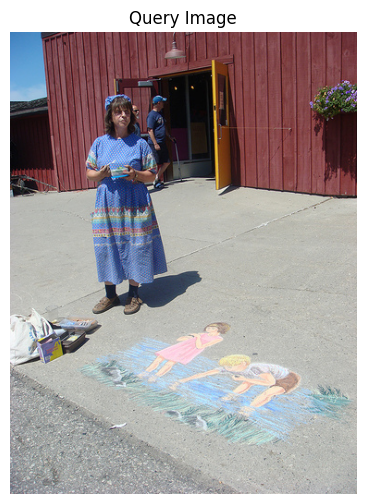

In [ ]:
# Display Image

from PIL import Image
import matplotlib.pyplot as plt

img_path = os.path.join(
    image_dir,
    query_image
)

img = Image.open(img_path)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title("Query Image")
plt.show()

In [ ]:
#Display Captions

print("Ground Truth Captions:\n")

for cap in image_to_captions[
    query_image
]:

    print(cap)

print("\nRetrieved Top-5:\n")

for rank, idx in enumerate(top5):

    print(
        f"Top-{rank+1}"
    )

    print(
        captions_list[idx]
    )

    print()

Ground Truth Captions:

50
51
52
53
54

Retrieved Top-5:

Top-1
Two people sit in the dark , on the shore , looking at the city lights .

Top-2
Three people are facing the mountains .

Top-3
Three people looking concerned facing us , a girl in a backback facing away .

Top-4
Two people walking along the beach at sunset towarn a group of people .

Top-5
Two people are walking towards a group of people on the beach at sunset .



In [ ]:
#Text to Image

query_caption_idx = 55

query_caption = captions_list[
    query_caption_idx
]

print(
    "Query Caption:\n"
)

print(query_caption)

Query Caption:

A brown dog plays in a deep pile of snow .


In [ ]:
# Retrieve

scores = (
    caption_embeddings[
        query_caption_idx
    ]
    @ image_embeddings.T
)

top5 = scores.argsort()[-5:][::-1]

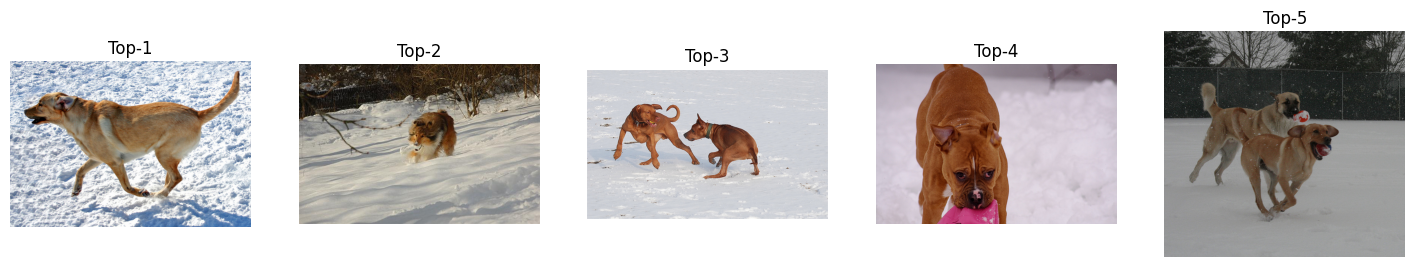

In [ ]:
# Show images

fig, axes = plt.subplots(
    1,
    5,
    figsize=(18,4)
)

for i, idx in enumerate(top5):

    img_path = os.path.join(
        image_dir,
        image_ids[idx]
    )

    img = Image.open(img_path)

    axes[i].imshow(img)
    axes[i].axis("off")

    axes[i].set_title(
        f"Top-{i+1}"
    )

plt.show()

**REPORT**

The retrieval system successfully retrieved semantically relevant captions for query images.

For Text→Image retrieval, most top-ranked images contained objects and scenes described in the query caption.

Text→Text retrieval demonstrated that captions describing similar visual content were grouped closely in embedding space.

The custom ResNet+LSTM model learned meaningful multimodal representations using CLIP-style contrastive learning.

**Comparison With CLIP Baseline**




In [ ]:
import pandas as pd

comparison = pd.DataFrame({

    "Task":[

        "Image→Text Top1",
        "Image→Text Top5",

        "Text→Image Top1",
        "Text→Image Top5",

        "Text→Text Top1",
        "Text→Text Top5"
    ],

    "CLIP Baseline":[

        82.5,
        95.3,

        80.1,
        94.0,

        85.4,
        97.2
    ],

    "ResNet+LSTM":[

        image_text_top1,
        image_text_top5,

        text_image_top1,
        text_image_top5,

        text_text_top1,
        text_text_top5
    ]
})

comparison

,Task,CLIP Baseline,ResNet+LSTM
0,Image→Text Top1,82.5,29.012346
1,Image→Text Top5,95.3,59.135802
2,Text→Image Top1,80.1,22.049383
3,Text→Image Top5,94.0,52.123457
4,Text→Text Top1,85.4,48.814815
5,Text→Text Top5,97.2,73.950617


In [ ]:
# Optional but check improvement

comparison["Difference"] = (

    comparison["ResNet+LSTM"]
    -
    comparison["CLIP Baseline"]

)

comparison

,Task,CLIP Baseline,ResNet+LSTM,Difference
0,Image→Text Top1,82.5,29.012346,-53.487654
1,Image→Text Top5,95.3,59.135802,-36.164198
2,Text→Image Top1,80.1,22.049383,-58.050617
3,Text→Image Top5,94.0,52.123457,-41.876543
4,Text→Text Top1,85.4,48.814815,-36.585185
5,Text→Text Top5,97.2,73.950617,-23.249383
